In [1]:
#Setup Gdrive file download extention 
!conda install -y gdown

Retrieving notices: ...working... done
Channels:
 - rapidsai
 - nvidia
 - conda-forge
 - defaults
 - pytorch
Platform: linux-64
Solving environment: done

## Package Plan ##

  environment location: /opt/conda

  added / updated specs:
    - gdown


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    ca-certificates-2024.7.4   |       hbcca054_0         151 KB  conda-forge
    certifi-2024.7.4           |     pyhd8ed1ab_0         156 KB  conda-forge
    filelock-3.15.4            |     pyhd8ed1ab_0          17 KB  conda-forge
    gdown-5.2.0                |     pyhd8ed1ab_0          21 KB  conda-forge
    openssl-3.3.1              |       h4ab18f5_1         2.8 MB  conda-forge
    ------------------------------------------------------------
                                           Total:         3.1 MB

The following NEW packages will be INSTALLED:

  filelock           conda-forge/noarc

In [2]:
# !gdown --id <File ID>
!gdown --id 1SdJEoAna8Z4bJ3_dJ23D4ldYlaxyWRor

/opt/conda/lib/python3.10/site-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1SdJEoAna8Z4bJ3_dJ23D4ldYlaxyWRor
From (redirected): https://drive.google.com/uc?id=1SdJEoAna8Z4bJ3_dJ23D4ldYlaxyWRor&confirm=t&uuid=9eb09a25-e6a6-46fe-a24a-cd9c9b7816ac
To: /kaggle/working/all Photos.zip
100%|██████████████████████████████████████| 1.81G/1.81G [00:26<00:00, 67.4MB/s]


In [3]:
!unzip 'all Photos.zip'

Archive:  all Photos.zip
  inflating: all Photos/1.jpg        
  inflating: all Photos/10.jpg       
  inflating: all Photos/100.jpg      
  inflating: all Photos/1000.jpg     
  inflating: all Photos/1001.jpg     
  inflating: all Photos/1002.jpg     
  inflating: all Photos/1003.jpg     
  inflating: all Photos/1004.jpg     
  inflating: all Photos/1005.jpg     
  inflating: all Photos/1006.jpg     
  inflating: all Photos/1007.jpg     
  inflating: all Photos/1008.jpg     
  inflating: all Photos/1009.jpg     
  inflating: all Photos/101.jpg      
  inflating: all Photos/1010.jpg     
  inflating: all Photos/1011.jpg     
  inflating: all Photos/1012.jpg     
  inflating: all Photos/1013.jpg     
  inflating: all Photos/1014.jpg     
  inflating: all Photos/1015.jpg     
  inflating: all Photos/1016.jpg     
  inflating: all Photos/1017.jpg     
  inflating: all Photos/1018.jpg     
  inflating: all Photos/1019.jpg     
  inflating: all Photos/102.jpg      
  inflating: all Photos/1

In [4]:
pip install transformers torchvision pandas scikit-learn


Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer
from torchvision import transforms
from PIL import Image
import os

# Load the CSV file
csv_path = '/kaggle/input/postcomm/Dataset_text.csv'
df = pd.read_csv(csv_path)

# Verify column names
print(df.columns)

# Drop unnecessary columns if they exist
columns_to_drop = [col for col in ['Source', 'Domain', 'Unnamed: 5'] if col in df.columns]
df = df.drop(columns_to_drop, axis=1)

# Shuffle the dataframe
df = shuffle(df, random_state=42)

# Split the dataset
train_ratio = 0.6
val_ratio = 0.2
test_ratio = 0.2

train_data, val_test = train_test_split(df, train_size=train_ratio, random_state=42)
valid_data, test_data = train_test_split(val_test, train_size=val_ratio / (val_ratio + test_ratio), random_state=42)


Index(['Image id', 'Caption', 'Label', 'Source', 'Domain', 'Unnamed: 5'], dtype='object')


In [7]:
"""image_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])"""

'image_transforms = transforms.Compose([\n    transforms.Resize((224, 224)),\n    transforms.ToTensor(),\n    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),\n])'

In [8]:
"""tokenizer = BertTokenizer.from_pretrained('sagorsarker/bangla-bert-base')"""

"tokenizer = BertTokenizer.from_pretrained('sagorsarker/bangla-bert-base')"

In [9]:
"""class MultimodalDataset(Dataset):
    def __init__(self, dataframe, images_folder, tokenizer, image_transforms, feature_extractor):
        self.dataframe = dataframe
        self.images_folder = images_folder
        self.tokenizer = tokenizer
        self.image_transforms = image_transforms
        self.feature_extractor = feature_extractor

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        text = row['Caption']
        label = row['Label']
        image_id = row['Image id']

        image_path_jpg = os.path.join(self.images_folder, f"{image_id}.jpg")
        image_path_png = os.path.join(self.images_folder, f"{image_id}.png")

        if os.path.exists(image_path_jpg):
            image_path = image_path_jpg
        elif os.path.exists(image_path_png):
            image_path = image_path_png
        else:
            raise FileNotFoundError(f"Image {image_id} not found with .jpg or .png extension")

        image = Image.open(image_path).convert('RGB')
        image = self.image_transforms(image)
        pixel_values = self.feature_extractor(images=image, return_tensors="pt").pixel_values.squeeze()

        text_inputs = self.tokenizer(text, return_tensors='pt', padding='max_length', truncation=True, max_length=128)

        label = int(label)
        assert 0 <= label < 2, f"Label {label} out of range"

        return {
            'original_text': text,
            'original_label': label,
            'input_ids': text_inputs['input_ids'].squeeze(),
            'attention_mask': text_inputs['attention_mask'].squeeze(),
            'pixel_values': pixel_values,
            'label': torch.tensor(label, dtype=torch.long)
        }
"""

'class MultimodalDataset(Dataset):\n    def __init__(self, dataframe, images_folder, tokenizer, image_transforms, feature_extractor):\n        self.dataframe = dataframe\n        self.images_folder = images_folder\n        self.tokenizer = tokenizer\n        self.image_transforms = image_transforms\n        self.feature_extractor = feature_extractor\n\n    def __len__(self):\n        return len(self.dataframe)\n\n    def __getitem__(self, idx):\n        row = self.dataframe.iloc[idx]\n        text = row[\'Caption\']\n        label = row[\'Label\']\n        image_id = row[\'Image id\']\n\n        image_path_jpg = os.path.join(self.images_folder, f"{image_id}.jpg")\n        image_path_png = os.path.join(self.images_folder, f"{image_id}.png")\n\n        if os.path.exists(image_path_jpg):\n            image_path = image_path_jpg\n        elif os.path.exists(image_path_png):\n            image_path = image_path_png\n        else:\n            raise FileNotFoundError(f"Image {image_id} not f

In [10]:
# Create datasets
images_folder = '/kaggle/working/all Photos/'
import torch
from torch.utils.data import DataLoader
from torchvision import transforms
from transformers import BertTokenizer, ViTFeatureExtractor
from sklearn.metrics import accuracy_score

"""# Prepare dataset
tokenizer = BertTokenizer.from_pretrained('sagorsarker/bangla-bert-base')
feature_extractor = ViTFeatureExtractor.from_pretrained('google/vit-base-patch16-224')
image_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=feature_extractor.image_mean, std=feature_extractor.image_std)
])

train_dataset = MultimodalDataset(train_data, images_folder, tokenizer, image_transforms, feature_extractor)
valid_dataset = MultimodalDataset(valid_data, images_folder, tokenizer, image_transforms, feature_extractor)
test_dataset = MultimodalDataset(test_data, images_folder, tokenizer, image_transforms, feature_extractor)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)"""


2024-07-10 17:12:03.087565: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-07-10 17:12:03.087673: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-07-10 17:12:03.223386: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


"# Prepare dataset\ntokenizer = BertTokenizer.from_pretrained('sagorsarker/bangla-bert-base')\nfeature_extractor = ViTFeatureExtractor.from_pretrained('google/vit-base-patch16-224')\nimage_transforms = transforms.Compose([\n    transforms.Resize((224, 224)),\n    transforms.ToTensor(),\n    transforms.Normalize(mean=feature_extractor.image_mean, std=feature_extractor.image_std)\n])\n\ntrain_dataset = MultimodalDataset(train_data, images_folder, tokenizer, image_transforms, feature_extractor)\nvalid_dataset = MultimodalDataset(valid_data, images_folder, tokenizer, image_transforms, feature_extractor)\ntest_dataset = MultimodalDataset(test_data, images_folder, tokenizer, image_transforms, feature_extractor)\n\ntrain_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)\nvalid_loader = DataLoader(valid_dataset, batch_size=16, shuffle=False)\ntest_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)"

In [29]:
print(len(train_dataset))
print(len(valid_dataset))
print(len(test_dataset))

3003
1001
1002


In [11]:
"""import os
import pandas as pd
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torch
import matplotlib.pyplot as plt
from transformers import AutoTokenizer
import torchvision.transforms as transforms

# Assuming your dataset class is already defined as MultimodalDataset
# Ensure you have defined your dataframe, images_folder, tokenizer, and image_transforms

# Example DataFrame
data = {
    'Caption': ['বাংলা টেক্সট ১', 'বাংলা টেক্সট ২'],
    'Label': [0, 1],
    'Image id': ['image1', 'image2']
}
dataframe = df

# Path to the images folder
#images_folder = 'path/to/images'

# Initialize tokenizer and image transforms
tokenizer = AutoTokenizer.from_pretrained('bert-base-multilingual-cased')
image_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=feature_extractor.image_mean, std=feature_extractor.image_std)
])
# Initialize dataset
dataset = MultimodalDataset(dataframe, images_folder, tokenizer, image_transforms)

# Create DataLoader
dataloader = DataLoader(dataset, batch_size=2, shuffle=True)

def imshow(image, ax=None, title=None, normalize=False):
    """Imshow for Tensor."""
    if ax is None:
        fig, ax = plt.subplots()
    image = image.numpy().transpose((1, 2, 0))
    if normalize:
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        image = std * image + mean
        image = np.clip(image, 0, 1)
    ax.imshow(image)
    if title is not None:
        ax.set_title(title)
    ax.axis('off')
    return ax

def print_samples(dataloader, num_samples=5):
    count = 0
    for batch in dataloader:
        if count >= num_samples:
            break
        for i in range(len(batch['original_text'])):
            if count >= num_samples:
                break
            print(f"Sample {count+1}:")
            print(f"Original Text: {batch['original_text'][i]}")
            if batch['original_label'][i] == 1:
                #print(f"Original Label: {batch['original_label'][i]}")
                print("Original Label: Commercial")
            else:
                print("Original Label: Non commercial")
            #print(f"Input IDs: {batch['input_ids'][i]}")
            #print(f"Attention Mask: {batch['attention_mask'][i]}")
            #print(f"Image Tensor: {batch['image'][i].shape}")
            #print(f"Label: {batch['label'][i]}")

            # Plot the image
            imshow(batch['image'][i])
            plt.show()
            print()
            count += 1

# Print some samples from the dataset
print_samples(dataloader)"""

SyntaxError: invalid syntax (3028054452.py, line 39)

In [ ]:
#pip install transformers


In [12]:
"""import torch
import torch.nn as nn
from transformers import BertModel, ViTModel

class MultimodalModel(nn.Module):
    def __init__(self, text_model_name='sagorsarker/bangla-bert-base', image_model_name='google/vit-base-patch16-224', num_labels=2):
        super(MultimodalModel, self).__init__()
        self.text_model = BertModel.from_pretrained(text_model_name)
        self.image_model = ViTModel.from_pretrained(image_model_name)

        self.classifier = nn.Linear(self.text_model.config.hidden_size + self.image_model.config.hidden_size, num_labels)

    def forward(self, input_ids, attention_mask, pixel_values):
        # Text embeddings
        text_outputs = self.text_model(input_ids=input_ids, attention_mask=attention_mask)
        text_embeds = text_outputs.last_hidden_state[:, 0, :]  # Use [CLS] token embedding

        # Image embeddings
        image_outputs = self.image_model(pixel_values=pixel_values)
        image_embeds = image_outputs.last_hidden_state[:, 0, :]  # Use [CLS] token embedding from ViT

        # Combine embeddings
        combined_embeds = torch.cat((text_embeds, image_embeds), dim=1)
        logits = self.classifier(combined_embeds)

        return logits

# Example usage
# model = MultimodalModel(num_labels=len(df['Label'].unique()))"""


"import torch\nimport torch.nn as nn\nfrom transformers import BertModel, ViTModel\n\nclass MultimodalModel(nn.Module):\n    def __init__(self, text_model_name='sagorsarker/bangla-bert-base', image_model_name='google/vit-base-patch16-224', num_labels=2):\n        super(MultimodalModel, self).__init__()\n        self.text_model = BertModel.from_pretrained(text_model_name)\n        self.image_model = ViTModel.from_pretrained(image_model_name)\n\n        self.classifier = nn.Linear(self.text_model.config.hidden_size + self.image_model.config.hidden_size, num_labels)\n\n    def forward(self, input_ids, attention_mask, pixel_values):\n        # Text embeddings\n        text_outputs = self.text_model(input_ids=input_ids, attention_mask=attention_mask)\n        text_embeds = text_outputs.last_hidden_state[:, 0, :]  # Use [CLS] token embedding\n\n        # Image embeddings\n        image_outputs = self.image_model(pixel_values=pixel_values)\n        image_embeds = image_outputs.last_hidden_sta

In [13]:
"""device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Instantiate model
model = MultimodalModel(num_labels=2)


# Define loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Training and validation loop
num_epochs = 10  # Set the number of epochs as required

for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    train_correct = 0
    total_train = 0
    
    for batch in train_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        pixel_values = batch['pixel_values'].to(device)
        labels = batch['label'].to(device)
        
        # Debugging statements
        print(f"Input IDs: {input_ids}")
        print(f"Attention Mask: {attention_mask}")
        print(f"Pixel Values: {pixel_values}")
        print(f"Labels: {labels}")

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask, pixel_values)
        
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_accuracy = train_correct / total_train
    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss/len(train_loader)}, Train Accuracy: {train_accuracy}")
    
    model.eval()
    valid_loss = 0
    valid_correct = 0
    total_valid = 0
    
    with torch.no_grad():
        for batch in valid_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            pixel_values = batch['pixel_values'].to(device)
            labels = batch['label'].to(device)

            outputs = model(input_ids, attention_mask, pixel_values)
            loss = criterion(outputs, labels)
            
            valid_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_valid += labels.size(0)
            valid_correct += (predicted == labels).sum().item()

    valid_accuracy = valid_correct / total_valid
    print(f"Epoch {epoch+1}/{num_epochs}, Valid Loss: {valid_loss/len(valid_loader)}, Valid Accuracy: {valid_accuracy}")

# Save the model
torch.save(model.state_dict(), 'multimodal_model_vit.pth')"""

'device = torch.device(\'cuda\' if torch.cuda.is_available() else \'cpu\')\n\n# Instantiate model\nmodel = MultimodalModel(num_labels=2)\n\n\n# Define loss and optimizer\ncriterion = nn.CrossEntropyLoss()\noptimizer = torch.optim.Adam(model.parameters(), lr=1e-4)\n\n# Training and validation loop\nnum_epochs = 10  # Set the number of epochs as required\n\nfor epoch in range(num_epochs):\n    model.train()\n    train_loss = 0\n    train_correct = 0\n    total_train = 0\n    \n    for batch in train_loader:\n        input_ids = batch[\'input_ids\'].to(device)\n        attention_mask = batch[\'attention_mask\'].to(device)\n        pixel_values = batch[\'pixel_values\'].to(device)\n        labels = batch[\'label\'].to(device)\n        \n        # Debugging statements\n        print(f"Input IDs: {input_ids}")\n        print(f"Attention Mask: {attention_mask}")\n        print(f"Pixel Values: {pixel_values}")\n        print(f"Labels: {labels}")\n\n        optimizer.zero_grad()\n        output

# With Custom Class

In [22]:
import torch
import torch.nn as nn
from torchvision import models

class CustomTransformerEncoder(nn.Module):
    def __init__(self, vocab_size, d_model, nhead, num_layers, max_length):
        super(CustomTransformerEncoder, self).__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.position_embedding = nn.Embedding(max_length, d_model)
        self.transformer_encoder = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model, nhead),
            num_layers
        )

    def forward(self, input_ids, attention_mask):
        position_ids = torch.arange(0, input_ids.size(1), dtype=torch.long, device=input_ids.device)
        position_ids = position_ids.unsqueeze(0).expand_as(input_ids)
        embedded = self.embedding(input_ids) + self.position_embedding(position_ids)
        mask = (attention_mask == 0)
        
        # Transpose mask to match the expected shape
        mask = mask.transpose(0, 1)
        
        encoded = self.transformer_encoder(embedded.transpose(0, 1), src_key_padding_mask=mask)
        return encoded.transpose(0, 1)


class CustomImageEncoder(nn.Module):
    def __init__(self, pretrained=True):
        super(CustomImageEncoder, self).__init__()
        resnet = models.resnet50(pretrained=pretrained)
        self.feature_extractor = nn.Sequential(*list(resnet.children())[:-1])  # Remove the last fully connected layer

    def forward(self, images):
        features = self.feature_extractor(images)
        features = features.view(features.size(0), -1)  # Flatten the tensor
        return features


In [23]:
class HierarchicalTextSplitMultimodalClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, max_length, num_layers, num_heads, num_classes=2):
        super(HierarchicalTextSplitMultimodalClassifier, self).__init__()
        # Custom text and image encoders
        self.text_encoder = CustomTransformerEncoder(vocab_size, embedding_dim, hidden_dim, max_length, num_layers, num_heads)
        self.image_encoder = CustomImageEncoder()
        
        # Self-attention layers for text features at different levels
        self.text_self_attention_low = nn.MultiheadAttention(embed_dim=hidden_dim, num_heads=8)
        self.text_self_attention_intermediate = nn.MultiheadAttention(embed_dim=hidden_dim, num_heads=8)
        self.text_self_attention_high = nn.MultiheadAttention(embed_dim=hidden_dim, num_heads=8)
        
        # Cross-attention layers for combining text and image features
        self.cross_attention_low = nn.MultiheadAttention(embed_dim=hidden_dim, num_heads=8)
        self.cross_attention_intermediate = nn.MultiheadAttention(embed_dim=hidden_dim, num_heads=8)
        self.cross_attention_high = nn.MultiheadAttention(embed_dim=hidden_dim, num_heads=8)
        
        # Fully connected layers for final classification
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 3 + 2048, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
    
    def forward(self, text_input, attention_mask, image_input):
        # Extract low, intermediate, and high-level features from text encoder
        text_features_all = self.text_encoder(text_input, attention_mask)
        text_features_low = text_features_all[:, :128, :]
        text_features_intermediate = text_features_all[:, 128:256, :]
        text_features_high = text_features_all[:, 256:, :]
        
        # Apply self-attention to text features at each level
        text_features_low, _ = self.text_self_attention_low(text_features_low, text_features_low, text_features_low)
        text_features_intermediate, _ = self.text_self_attention_intermediate(text_features_intermediate, text_features_intermediate, text_features_intermediate)
        text_features_high, _ = self.text_self_attention_high(text_features_high, text_features_high, text_features_high)
        
        # Extract image features from image encoder
        image_features = self.image_encoder(image_input)
        
        # Apply cross-attention between text and image features at each level
        text_features_low, _ = self.cross_attention_low(text_features_low, image_features.unsqueeze(1), image_features.unsqueeze(1))
        text_features_intermediate, _ = self.cross_attention_intermediate(text_features_intermediate, image_features.unsqueeze(1), image_features.unsqueeze(1))
        text_features_high, _ = self.cross_attention_high(text_features_high, image_features.unsqueeze(1), image_features.unsqueeze(1))
        
        # Concatenate features from all levels
        combined_features = torch.cat((text_features_low.squeeze(1), text_features_intermediate.squeeze(1), text_features_high.squeeze(1), image_features), dim=1)
        
        # Pass through fully connected layers for classification
        logits = self.fc(combined_features)
        
        return logits


In [24]:
import os
from torch.utils.data import Dataset
from PIL import Image
import torch
from transformers import BertTokenizer
from torchvision import transforms

class MultimodalDataset(Dataset):
    def __init__(self, dataframe, images_folder, tokenizer, image_transforms):
        self.dataframe = dataframe
        self.images_folder = images_folder
        self.tokenizer = tokenizer
        self.image_transforms = image_transforms

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        text = row['Caption']
        label = row['Label']
        image_id = row['Image id']

        image_path_jpg = os.path.join(self.images_folder, f"{image_id}.jpg")
        image_path_png = os.path.join(self.images_folder, f"{image_id}.png")

        if os.path.exists(image_path_jpg):
            image_path = image_path_jpg
        elif os.path.exists(image_path_png):
            image_path = image_path_png
        else:
            raise FileNotFoundError(f"Image {image_id} not found with .jpg or .png extension")

        image = Image.open(image_path).convert('RGB')
        image = self.image_transforms(image)

        text_inputs = self.tokenizer(text, return_tensors='pt', padding='max_length', truncation=True, max_length=128)

        label = int(label)
        assert 0 <= label < 2, f"Label {label} out of range"

        return {
            'original_text': text,
            'original_label': label,
            'input_ids': text_inputs['input_ids'].squeeze(),
            'attention_mask': text_inputs['attention_mask'].squeeze(),
            'pixel_values': image,
            'label': torch.tensor(label, dtype=torch.long)
        }

# Define image transformations
image_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Instantiate tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

images_folder = '/kaggle/working/all Photos/'
# Create dataset and dataloader
train_dataset = MultimodalDataset(train_data, images_folder, tokenizer, image_transforms)
valid_dataset = MultimodalDataset(valid_data, images_folder, tokenizer, image_transforms)
test_dataset = MultimodalDataset(test_data, images_folder, tokenizer, image_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


In [26]:
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Define model parameters
vocab_size = tokenizer.vocab_size
d_model = 512
nhead = 8
num_layers = 6
max_length = 128
num_classes = 2

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = HierarchicalTextSplitMultimodalClassifier(vocab_size, d_model, nhead, num_layers, max_length, num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
num_epochs = 5

for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    train_correct = 0
    total_train = 0

    for batch in train_loader:
        text_input = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        image_input = batch['pixel_values'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(text_input, attention_mask, image_input)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        train_correct += (predicted == labels).sum().item()
        total_train += labels.size(0)

    train_accuracy = train_correct / total_train

    model.eval()
    valid_loss = 0
    valid_correct = 0
    total_valid = 0

    with torch.no_grad():
        for batch in valid_loader:
            text_input = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            image_input = batch['pixel_values'].to(device)
            labels = batch['label'].to(device)

            outputs = model(text_input, attention_mask, image_input)
            loss = criterion(outputs, labels)

            valid_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            valid_correct += (predicted == labels).sum().item()
            total_valid += labels.size(0)

    valid_accuracy = valid_correct / total_valid

    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss/len(train_loader)}, Train Accuracy: {train_accuracy}, Valid Loss: {valid_loss/len(valid_loader)}, Valid Accuracy: {valid_accuracy}")

# Testing loop
#model.eval()
# Save the model
torch.save(model.state_dict(), 'hierarchical_multimodal_model.pth')

TypeError: CustomTransformerEncoder.__init__() takes 6 positional arguments but 7 were given

In [ ]:
# Prediction loop
model.eval()
all_labels = []
all_preds = []

with torch.no_grad():
    for batch in test_loader:
        text_input = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        image_input = batch['pixel_values'].to(device)
        labels = batch['label'].to(device)

        outputs = model(text_input, attention_mask, image_input)
        _, predicted = torch.max(outputs, 1)
        
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())

# Calculate test accuracy
test_accuracy = accuracy_score(all_labels, all_preds)
print(f"Test Accuracy: {test_accuracy}")


In [63]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer
from torchvision import transforms
from PIL import Image
import pandas as pd

class MultimodalDataset(Dataset):
    def __init__(self, dataframe, images_folder, tokenizer, image_transforms):
        self.dataframe = dataframe
        self.images_folder = images_folder
        self.tokenizer = tokenizer
        self.image_transforms = image_transforms

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        text = row['Caption']
        label = row['Label']
        image_id = row['Image id']

        image_path_jpg = os.path.join(self.images_folder, f"{image_id}.jpg")
        image_path_png = os.path.join(self.images_folder, f"{image_id}.png")

        if os.path.exists(image_path_jpg):
            image_path = image_path_jpg
        elif os.path.exists(image_path_png):
            image_path = image_path_png
        else:
            raise FileNotFoundError(f"Image {image_id} not found with .jpg or .png extension")

        image = Image.open(image_path).convert('RGB')
        image = self.image_transforms(image)

        text_inputs = self.tokenizer(text, return_tensors='pt', padding='max_length', truncation=True, max_length=128)

        label = int(label)
        assert 0 <= label < 2, f"Label {label} out of range"

        return {
            'original_text': text,
            'original_label': label,
            'input_ids': text_inputs['input_ids'].squeeze(),
            'attention_mask': text_inputs['attention_mask'].squeeze(),
            'pixel_values': image,
            'label': torch.tensor(label, dtype=torch.long)
        }

class CustomTransformerEncoder(nn.Module):
    def __init__(self, vocab_size, d_model, nhead, num_layers, max_length):
        super(CustomTransformerEncoder, self).__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.position_embedding = nn.Embedding(max_length, d_model)
        self.transformer_encoder = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model, nhead),
            num_layers
        )

    def forward(self, input_ids, attention_mask):
        position_ids = torch.arange(0, input_ids.size(1), dtype=torch.long, device=input_ids.device)
        position_ids = position_ids.unsqueeze(0).expand_as(input_ids)
        embedded = self.embedding(input_ids) + self.position_embedding(position_ids)
        
        # The attention mask needs to have shape (batch_size, seq_length) for key_padding_mask
        mask = attention_mask == 0  # Convert to boolean mask where padding tokens are marked as True
        
        encoded = self.transformer_encoder(embedded.transpose(0, 1), src_key_padding_mask=mask)
        return encoded.transpose(0, 1)

class HierarchicalTextSplitMultimodalClassifier(nn.Module):
    def __init__(self, vocab_size, d_model, nhead, num_layers, max_length, num_classes):
        super(HierarchicalTextSplitMultimodalClassifier, self).__init__()
        self.text_encoder = CustomTransformerEncoder(vocab_size, d_model, nhead, num_layers, max_length)
        self.image_encoder = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Flatten(),
            nn.Linear(32 * 56 * 56, 512),
            nn.ReLU()
        )
        self.fc = nn.Linear(512 + d_model, num_classes)

    def forward(self, text_input, attention_mask, image_input):
        text_features_all = self.text_encoder(text_input, attention_mask)
        
        seq_len = text_features_all.size(1)
        text_features_low = text_features_all[:, :seq_len // 3, :]
        text_features_intermediate = text_features_all[:, seq_len // 3:2 * seq_len // 3, :]
        text_features_high = text_features_all[:, 2 * seq_len // 3:, :]

        image_features = self.image_encoder(image_input)

        combined_features = torch.cat((image_features, text_features_high[:, 0, :]), dim=1)
        logits = self.fc(combined_features)
        return logits

# Define image transformations
image_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Instantiate tokenizer
from transformers import XLMRobertaTokenizer
#tokenizer = BertTokenizer.from_pretrained('xlm-roberta-base')
#tokenizer = XLMRobertaTokenizer.from_pretrained('xlm-roberta-base')
tokenizer = BertTokenizer.from_pretrained('sagorsarker/bangla-bert-base')

images_folder = '/kaggle/working/all Photos/'
# Assuming `train_dataframe`, `valid_dataframe`, `test_dataframe` are predefined
train_dataset = MultimodalDataset(train_data, images_folder, tokenizer, image_transforms)
valid_dataset = MultimodalDataset(valid_data, images_folder, tokenizer, image_transforms)
test_dataset = MultimodalDataset(test_data, images_folder, tokenizer, image_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Define model parameters
vocab_size = tokenizer.vocab_size
d_model = 512
nhead = 8
num_layers = 6
max_length = 128
num_classes = 2

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = HierarchicalTextSplitMultimodalClassifier(vocab_size, d_model, nhead, num_layers, max_length, num_classes).to(device)

print('criterion er upore')
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=2e-4)

# Training loop
num_epochs = 10
print('train epoch e dhukse')
for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    train_correct = 0
    total_train = 0
    print('epoch : ', epoch)
    for batch in train_loader:
        text_input = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        image_input = batch['pixel_values'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(text_input, attention_mask, image_input)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        train_correct += (predicted == labels).sum().item()
        total_train += labels.size(0)

    train_accuracy = train_correct / total_train
    print('train_acc : ', train_accuracy)

    model.eval()
    valid_loss = 0
    valid_correct = 0
    total_valid = 0

    with torch.no_grad():
        print('valid e dhukse')
        for batch in valid_loader:
            text_input = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            image_input = batch['pixel_values'].to(device)
            labels = batch['label'].to(device)

            outputs = model(text_input, attention_mask, image_input)
            loss = criterion(outputs, labels)

            valid_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            valid_correct += (predicted == labels).sum().item()
            total_valid += labels.size(0)

    valid_accuracy = valid_correct / total_valid

    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss/len(train_loader)}, Train Accuracy: {train_accuracy}, Valid Loss: {valid_loss/len(valid_loader)}, Valid Accuracy: {valid_accuracy}")

# Testing loop
"""model.eval()
test_correct = 0
total_test = 0

with torch.no_grad():
    for batch in test_loader:
        text_input = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        image_input = batch['pixel_values'].to(device)
        labels = batch['label'].to(device)

        outputs = model(text_input, attention_mask, image_input)
        _, predicted = torch.max(outputs, 1)
        test_correct += (predicted == labels).sum().item()
        total_test += labels.size(0)

test_accuracy = test_correct / total_test
print(f"Test Accuracy: {test_accuracy}")"""


vocab.txt:   0%|          | 0.00/2.24M [00:00<?, ?B/s]

/opt/conda/lib/python3.10/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/491 [00:00<?, ?B/s]

/opt/conda/lib/python3.10/site-packages/torch/nn/modules/transformer.py:282: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


criterion er upore
train epoch e dhukse
epoch :  0
train_acc :  0.5800865800865801
valid e dhukse
Epoch 1/10, Train Loss: 0.792442631848315, Train Accuracy: 0.5800865800865801, Valid Loss: 0.6333311488851905, Valid Accuracy: 0.6243756243756243
epoch :  1
train_acc :  0.644022644022644
valid e dhukse
Epoch 2/10, Train Loss: 0.6173001521445335, Train Accuracy: 0.644022644022644, Valid Loss: 0.6145589305087924, Valid Accuracy: 0.6543456543456544
epoch :  2
train_acc :  0.7106227106227107
valid e dhukse
Epoch 3/10, Train Loss: 0.549246185954581, Train Accuracy: 0.7106227106227107, Valid Loss: 0.48451323062181473, Valid Accuracy: 0.7772227772227772
epoch :  3
train_acc :  0.8158508158508159
valid e dhukse
Epoch 4/10, Train Loss: 0.4034480495338744, Train Accuracy: 0.8158508158508159, Valid Loss: 0.4232146362774074, Valid Accuracy: 0.8301698301698301
epoch :  4
train_acc :  0.8884448884448884
valid e dhukse
Epoch 5/10, Train Loss: 0.2794632411542091, Train Accuracy: 0.8884448884448884, Valid

'model.eval()\ntest_correct = 0\ntotal_test = 0\n\nwith torch.no_grad():\n    for batch in test_loader:\n        text_input = batch[\'input_ids\'].to(device)\n        attention_mask = batch[\'attention_mask\'].to(device)\n        image_input = batch[\'pixel_values\'].to(device)\n        labels = batch[\'label\'].to(device)\n\n        outputs = model(text_input, attention_mask, image_input)\n        _, predicted = torch.max(outputs, 1)\n        test_correct += (predicted == labels).sum().item()\n        total_test += labels.size(0)\n\ntest_accuracy = test_correct / total_test\nprint(f"Test Accuracy: {test_accuracy}")'

In [64]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

def evaluate_model(model, test_loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            images = batch['pixel_values'].to(device)
            labels = batch['label'].to(device)

            outputs = model(input_ids, attention_mask, images)
            _, preds = torch.max(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_labels = ['Commercial' if label == 1 else 'Non commercial' for label in all_labels]
    all_preds = ['Commercial' if pred == 1 else 'Non commercial' for pred in all_preds]
    
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall = recall_score(all_labels, all_preds, average='weighted')
    f1 = f1_score(all_labels, all_preds, average='weighted')
    report = classification_report(all_labels, all_preds, target_names=['Non commercial', 'Commercial'])

    return accuracy, precision, recall, f1, report, all_labels, all_preds

# Example usage:
accuracy, precision, recall, f1, report, all_labels, all_preds = evaluate_model(model, test_loader)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print("\nClassification Report:")
print(report)


Accuracy: 0.9042
Precision: 0.9041
Recall: 0.9042
F1 Score: 0.9041

Classification Report:
                precision    recall  f1-score   support

Non commercial       0.91      0.92      0.92       573
    Commercial       0.89      0.88      0.89       429

      accuracy                           0.90      1002
     macro avg       0.90      0.90      0.90      1002
  weighted avg       0.90      0.90      0.90      1002



In [65]:
def plot_confusion_matrix(all_labels, all_preds):
    labels = ['Commercial', 'Non commercial']
    cm = confusion_matrix(all_labels, all_preds, labels=labels)
    plt.figure(figsize=(8, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.savefig('/kaggle/working/bangla_bert_base+custom_out_att_confusion_matrix.png')
    plt.show()
    

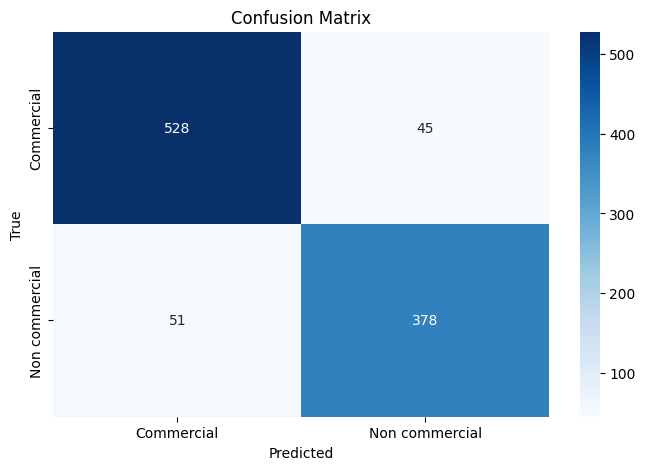

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns
plot_confusion_matrix(all_labels, all_preds)